# Debugging a Language Model

Most people approach mechanistic interpretability like biology: dissect the network, catalog what's there, name the parts. I think this is the wrong instinct. The useful move is closer to debugging a program you didn't write, where you don't inventory every organ, you binary-search for the line that's wrong. This is that binary search, worked through on one concrete failure, start to finish.

I'm going to call the thing it finds the diffuse mover: a factual attribute that doesn't get relayed from subject token to output by one dedicated head, but by a small cluster of late-layer heads, here roughly L8 through L10, each carrying a partial, redundant copy of the signal. Whether that's true of factual recall generally, or just true of this one Paris/France fact, I haven't checked.

Model is GPT-2-small, poked at with TransformerLens (Neel Nanda), which is what lets you hook into an internal activation directly instead of hand-rolling the plumbing yourself.

## Setup

We'll use [TransformerLens](https://github.com/TransformerLensOrg/TransformerLens) (Neel Nanda), which exposes every internal activation of a GPT-2-style model as a hookable point: this is what lets us patch, ablate, and read out activations without hand-rolling forward-hook plumbing. Model is GPT-2-small: small enough to iterate on quickly, well-studied enough that we can sanity-check our findings against the literature (Meng et al., "Locating and Editing Factual Associations in GPT," and Geva et al., "Dissecting Recall of Factual Associations in Auto-Regressive Language Models," are the references for factual-recall circuits like the one below).

In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformer_lens import HookedTransformer, patching

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model = HookedTransformer.from_pretrained("gpt2", device=device)
model.eval();

cuda


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1937.00it/s]


Loaded pretrained model gpt2 into HookedTransformer


## 1. Pick a bug

You need two prompts: a **clean** prompt where the model gets it right, and a **corrupted** prompt, the same sentence with one thing changed, where it doesn't. The gap between them is what you're going to trace.

The factual-recall example: "Paris is the capital of" should complete with " France." Corrupt it by swapping the subject city for a different capital ("Moscow is the capital of"), and the model's preference should flip to the *other* country entirely, not just weaken, since the sentence now genuinely asks about a different fact.

The single number we'll track throughout is **logit difference**: the model's logit for the correct country minus its logit for the competing one.

> Positive and large = confidently answering the question in the clean prompt.

> Near zero or negative = confidently answering the *other* question.

Every step below is really just: do something to the model, watch this number move, and use that as evidence for what mattered.

In [8]:
clean_prompt = "Paris is the capital of"
corrupted_prompt = "Moscow is the capital of"

correct_name = " France"
incorrect_name = " Russia"

correct_token = model.to_single_token(correct_name)
incorrect_token = model.to_single_token(incorrect_name)

clean_tokens = model.to_tokens(clean_prompt)
corrupted_tokens = model.to_tokens(corrupted_prompt)

def logit_diff(logits, correct=correct_token, incorrect=incorrect_token):
    """logits: [batch, seq_len, vocab_size]. We only care about the final
    position's prediction, and only about the two candidate tokens."""
    final_logits = logits[:, -1, :]
    return (final_logits[:, correct] - final_logits[:, incorrect]).mean()

clean_logits, clean_cache = model.run_with_cache(clean_tokens)
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

clean_diff = logit_diff(clean_logits)
corrupted_diff = logit_diff(corrupted_logits)

print(f"clean logit diff:     {clean_diff.item():.3f}")
print(f"corrupted logit diff: {corrupted_diff.item():.3f}")

clean logit diff:     5.175
corrupted logit diff: -7.532


This is expected, and it's the sanity check the whole rest of the notebook depends on: the model correctly continues "France" for the clean prompt and "Russia" for the corrupted one, so clean lands positive and corrupted lands negative. If these two numbers weren't cleanly separated we'd have picked a bad example, not a bug worth tracing.

## 2. Localize the layer

Here's the core trick, and it's worth being precise about it before reaching for the library function. We run the corrupted prompt, but at one specific point in the network we reach in and overwrite the activation with the corresponding activation from the *clean* run, then let the rest of the forward pass continue as normal. If patching in that one clean activation recovers the correct answer, we've learned that activation was carrying the information the model needed. If it does nothing, that activation wasn't the bottleneck.

It's a bit like tracing a rattle in a car by swapping one part at a time for a known-good one and listening for whether the rattle stops: you're not disassembling the whole engine, you're isolating by substitution.

We do this at every (layer, token position) pair and plot the result as a heatmap. Bright regions are where the clean information mattered.

100%|██████████| 72/72 [00:02<00:00, 35.95it/s]


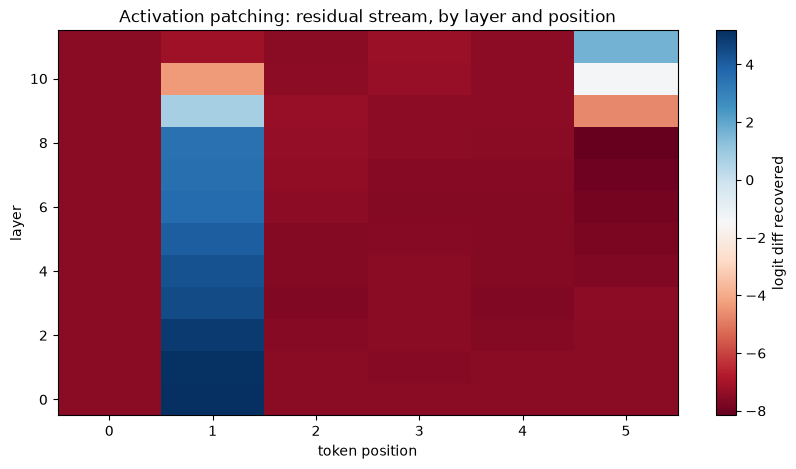

In [9]:
def metric(logits):
    return logit_diff(logits)

# Patch the pre-attention residual stream: overwrite run B's activation at
# (layer, position) with run A's, before that layer does anything with it.
patching_result = patching.get_act_patch_resid_pre(
    model, corrupted_tokens, clean_cache, metric
)

plt.figure(figsize=(10, 5))
plt.imshow(patching_result.cpu().numpy(), aspect="auto", cmap="RdBu", origin="lower")
plt.colorbar(label="logit diff recovered")
plt.xlabel("token position")
plt.ylabel("layer")
plt.title("Activation patching: residual stream, by layer and position")
plt.show()

Two things are going on in this heatmap, and they shouldn't be read as one finding.

The first column (the "Paris"/"Moscow" token position) is bright at every layer, including layer 0. That's not a discovery, it's a tautology: patching `resid_pre` there just overwrites the subject token's identity outright, and layer 0's `resid_pre` is essentially the embedding. Of course the clean answer comes back, as we handed it the clean subject.

The informative column is the last position, " of", where the model actually emits its answer. Patching there does close to nothing through layer 8, then jumps sharply across layers 9 through 11 (roughly -4.72, then -1.38, then +1.68). That's the window where whatever represents "France" gets moved from the subject position over to the final position to be read out.

## 3. Localize the head

A layer is still a lot of machinery: dozens of attention heads and an MLP. Same trick, finer grain: patch individual attention head outputs instead of the whole residual stream, and narrow "layer 9" down to "layer 9, head 6."

100%|██████████| 144/144 [00:03<00:00, 37.37it/s]


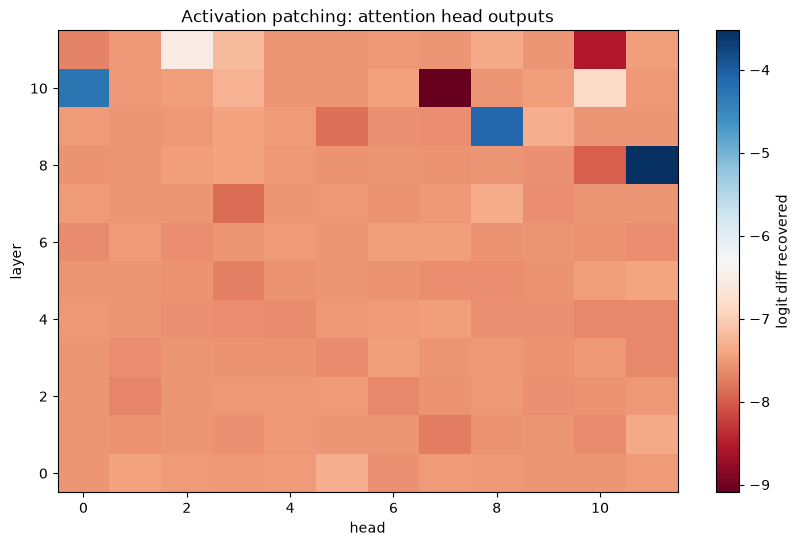

In [10]:
head_patching_result = patching.get_act_patch_attn_head_out_all_pos(
    model, corrupted_tokens, clean_cache, metric
)

plt.figure(figsize=(10, 6))
plt.imshow(head_patching_result.cpu().numpy(), aspect="auto", cmap="RdBu", origin="lower")
plt.colorbar(label="logit diff recovered")
plt.xlabel("head")
plt.ylabel("layer")
plt.title("Activation patching: attention head outputs")
plt.show()

Consistent with the layer/position result above: the winning heads all sit in layers 8 through 11, right where the residual-stream effect jumped. The top single head is L8H11, which alone recovers the logit diff from -7.53 to -3.53, about 32% of the way back to the clean value of 5.17. The runners-up are close behind but not close enough to call it a tie: L9H8 lands at -4.12, L10H0 at -4.27.

No single head fully closes the gap. That's the first hint that this isn't a one-head circuit, and it's worth sitting with that hint rather than rushing past it, because step 4 is about to make the one-head story look more convincing than it is.

## 4. Read out what it's doing

Localizing a head tells you *where*, not *what*. The cheap way to find out what it's actually doing: look at where it attends, on this specific prompt.

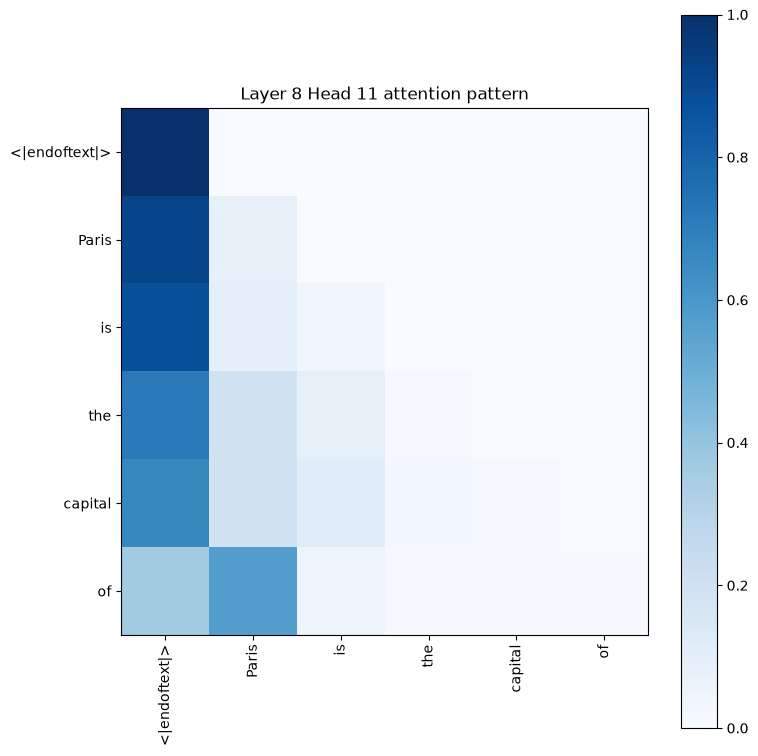

In [11]:
LAYER, HEAD = 8, 11

attn_pattern = clean_cache["pattern", LAYER][0, HEAD]
str_tokens = model.to_str_tokens(clean_prompt)

plt.figure(figsize=(8, 8))
plt.imshow(attn_pattern.cpu().numpy(), cmap="Blues")
plt.xticks(range(len(str_tokens)), str_tokens, rotation=90)
plt.yticks(range(len(str_tokens)), str_tokens)
plt.title(f"Layer {LAYER} Head {HEAD} attention pattern")
plt.colorbar()
plt.tight_layout()
plt.show()

Yes, plainly: from the final position (" of"), this head puts 0.569 of its attention on "Paris", more than everything else combined except the BOS token (0.361, the usual attention sink — every head does this to some degree, so I wouldn't read much into it here). Nothing else gets more than 0.05.

So the story the localization steps were telling — an L8-11 head reads the subject token to produce the answer — is at least visible in this one attention pattern, not just inferred from the patching numbers. That's real evidence. It's also, on its own, only narration: a head can attend to the right place and still not be load-bearing. Step 5 is the actual test.

## 5. Confirm with an intervention

This is the step that actually inspired the "debugging, not anatomy" framing. Looking at a head and describing what it seems to do is still narration. The test is whether editing it breaks the behavior in the way your story predicts. We zero-ablate the head we found and check whether the model's preference for the correct name collapses.

In [12]:
def zero_ablate_head(z, hook, head=HEAD):
    z[:, :, head, :] = 0.0
    return z

ablated_logits = model.run_with_hooks(
    clean_tokens,
    fwd_hooks=[(f"blocks.{LAYER}.attn.hook_z", zero_ablate_head)],
)

ablated_diff = logit_diff(ablated_logits)

print(f"clean logit diff:   {clean_diff.item():.3f}")
print(f"ablated logit diff: {ablated_diff.item():.3f}")

clean logit diff:   5.175
ablated logit diff: 4.061


It only partially does: the clean logit diff of 5.175 drops to 4.061, a fall of about 1.1 or roughly 21 percent, nowhere near the corrupted-run value of -7.53. So L8H11 is not "the France head." Removing it barely dents the model's confidence, and that disagrees with the story step 4 was tempting us to tell, where one head reads the subject and the case is closed. It isn't closed: patching L8H11, L9H8, or L10H0 alone each gets you partway and no further, which reads more like a handful of heads sharing the job than one owning it outright. Whether they're redundant, each independently sufficient, or complementary, each carrying a different piece and jointly necessary, isn't something this trace distinguishes, since that would need patching combinations of heads together rather than one at a time. That's the natural next step, and not one I've run here.

---

*Anatomy tells you what lit up. Debugging tells you what held up.*